![NVIDIA Logo](images/nvidia.png)

# Exercise: Add Metadata to Control Message

For this exercise you'll be working with our simple user authentication logs. Your goal is to create a pipeline that accomplishes the following:

- Reads in the logs from `data/simple_user_log.jsonlines`.
- Converts the incoming `MessageMeta` messages into `ControlMessage` messages.
- Adds the following metadata to the pipeline's control messages.
  - `"log_type": "auth_logs", "source": "web_server_1"`

To support your work, we are importing the `AddMetadataAndTaskStage` from the previous notebook for use in your pipeline.

In [1]:
from add_metadata_and_tasks_stage import AddMetadataAndTaskStage

In [2]:
help(AddMetadataAndTaskStage)

Help on class AddMetadataAndTaskStage in module add_metadata_and_tasks_stage:

class AddMetadataAndTaskStage(morpheus.pipeline.pass_thru_type_mixin.PassThruTypeMixin, morpheus.pipeline.execution_mode_mixins.GpuAndCpuMixin, morpheus.pipeline.single_port_stage.SinglePortStage)
 |  AddMetadataAndTaskStage(config: morpheus.config.Config, metadata: dict = None, tasks: dict = None)
 |  
 |  A Morpheus pipeline stage that adds metadata and tasks to incoming ControlMessages.
 |  
 |  This stage allows for augmenting ControlMessages with additional metadata (key-value pairs)
 |  and processing tasks (instructions that define SIMD operations on the payload). It enables
 |  more flexible and dynamic processing within a Morpheus pipeline.
 |  
 |  Attributes:
 |      _metadata (dict, optional): A dictionary of metadata key-value pairs to be added to each message.
 |      _tasks (dict, optional): A dictionary of task definitions, where keys are task names and values
 |                              

---

## Imports

You will likely need to use the following imports in your work.

In [3]:
import typing
import logging

from IPython.display import Image

import cudf

from morpheus.config import Config
from morpheus.pipeline import LinearPipeline

from morpheus.stages.input.file_source_stage import FileSourceStage
from morpheus.stages.output.in_memory_sink_stage import InMemorySinkStage
from morpheus.stages.preprocess.deserialize_stage import DeserializeStage
from morpheus.stages.postprocess.serialize_stage import SerializeStage
from add_metadata_and_tasks_stage import AddMetadataAndTaskStage, add_metadata_and_tasks

from morpheus.messages import ControlMessage

from morpheus.pipeline.execution_mode_mixins import GpuAndCpuMixin
from morpheus.pipeline.pass_thru_type_mixin import PassThruTypeMixin
from morpheus.pipeline.single_port_stage import SinglePortStage

from morpheus.cli.register_stage import register_stage

from morpheus.utils.logger import configure_logging, reset_logging

import mrc
from mrc.core import operators as ops

---

## Your Work Here

Build and run your pipeline in the space provided below. By all means feel free to create additional code cells for your work, which you can do by clicking the `+` button in the Jupyter menu bar at the top of this notebook.

If you get stuck, a solution is provided below, which you view by expanding the *Solution* section below.

In [4]:
@register_stage("add-meta")
class AddMeta(PassThruTypeMixin, GpuAndCpuMixin, SinglePortStage):
    def __init__(self, c: Config, meta: dict=None, task: dict=None):
        # {"key":5}
        super().__init__(c)
        self._meta = meta
        self._task = task
    @property
    def name(self) -> str:
        return "add-meta"
    def accepted_types(self) -> tuple:
        return (ControlMessage, )
    def supports_cpp_node(self) -> bool:
        return False
    def on_data(self, message:ControlMessage) -> ControlMessage:
        cm = add_metadata_and_task(message, tasks=self._task, metadata=self._meta)
        return cm
    def _build_single(self, builder: mrc.Builder, input_node: mrc.SegmentObject) -> mrc.SegmentObject:
        node = builder.make_node(self.unique_name, ops.map(self.on_data))
        builder.make_edge(input_node, node)
        return node

In [5]:
config = Config()
pipeline = LinearPipeline(config)

In [6]:
input_file="data/simple_user_log.jsonlines"
pipeline.set_source(FileSourceStage(config, filename=input_file, iterative=False))
pipeline.add_stage(DeserializeStage(config))
pipeline.add_stage(AddMeta(config, meta={"tracing": True}, task={"filter":
                [{"ip":  "127.0.0.1"}, {"port": "446"}]}))
in_mem = pipeline.add_stage(InMemorySinkStage(config))

In [7]:
pipeline.build()

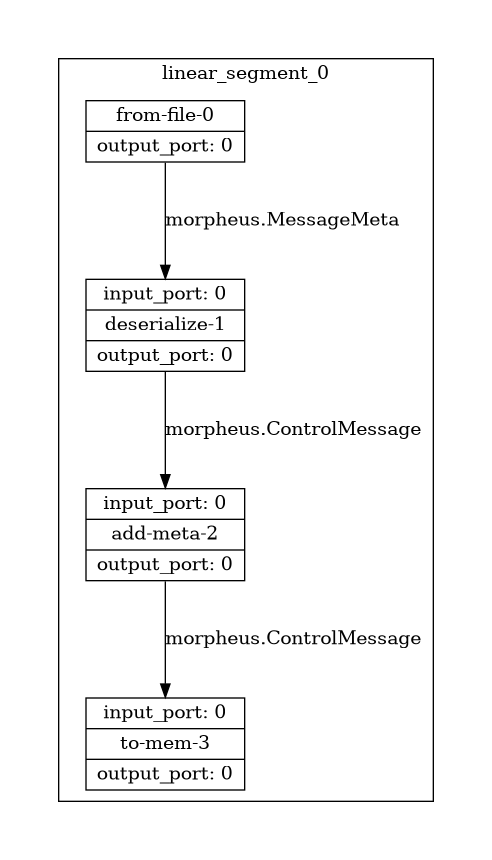

In [8]:
viz_file = "pipeline_visualizations/ex34.png"
pipeline.visualize(viz_file)
Image(viz_file)

In [9]:
reset_logging()
configure_logging(log_level=logging.DEBUG)

====Starting Pipeline====
====Pipeline Started====
====Building Segment: linear_segment_0====
Added source: <from-file-0; FileSourceStage(filename=data/simple_user_log.jsonlines, iterative=False, file_type=FileTypes.Auto, repeat=1, filter_null=True, filter_null_columns=None, parser_kwargs=None)>
  └─> morpheus.MessageMeta
Added stage: <deserialize-1; DeserializeStage(ensure_sliceable_index=True, task_type=None, task_payload=None)>
  └─ morpheus.MessageMeta -> morpheus.ControlMessage
Added stage: <add-meta-2; AddMeta(meta={'tracing': True}, task={'filter': [{'ip': '127.0.0.1'}, {'port': '446'}]})>
  └─ morpheus.ControlMessage -> morpheus.ControlMessage
Added stage: <to-mem-3; InMemorySinkStage()>
  └─ morpheus.ControlMessage -> morpheus.ControlMessage
====Building Segment Complete!====


Exception occurred in pipeline. Rethrowing
Traceback (most recent call last):
  File "/opt/conda/envs/morpheus/lib/python3.10/site-packages/morpheus/pipeline/pipeline.py", line 408, in post_start
    await executor.join_async()
  File "/tmp/ipykernel_2145/1175560587.py", line 16, in on_data
    cm = add_metadata_and_task(message, tasks=self._task, metadata=self._meta)
NameError: name 'add_metadata_and_task' is not defined. Did you mean: 'add_metadata_and_tasks'?


====Pipeline Complete====


In [10]:
await pipeline.run_async()

E20250923 06:08:47.766569 139690403419712 context.cpp:124] /linear_segment_0/add-meta-2; rank: 0; size: 1; tid: 139690403419712: set_exception issued; issuing kill to current runnable. Exception msg: NameError: name 'add_metadata_and_task' is not defined

At:
  /tmp/ipykernel_2145/1175560587.py(16): on_data
E20250923 06:08:47.782546 139696636188480 runner.cpp:189] Runner::await_join - an exception was caught while awaiting on one or more contexts/instances - rethrowing
E20250923 06:08:47.782602 139696636188480 segment_instance.cpp:273] segment::SegmentInstance - an exception was caught while awaiting on one or more nodes - rethrowing
E20250923 06:08:47.782617 139696636188480 service.cpp:224] Service[segment::SegmentInstance]: caught exception in service_await_join: NameError: name 'add_metadata_and_task' is not defined

At:
  /tmp/ipykernel_2145/1175560587.py(16): on_data
E20250923 06:08:47.782641 139696636188480 pipeline_instance.cpp:230] pipeline::PipelineInstance - an exception was 

NameError: name 'add_metadata_and_task' is not defined

In [ ]:
cm = in_mem.get_messages()[0]
cm.get_tasks()

In [ ]:
cm.get_metadata()

In [ ]:
mm = cm.payload()
df = mm.copy_dataframe()

---

## Solution

In [ ]:
input_file = "data/simple_user_log.jsonlines"

In [ ]:
# Define dictionary with desired metadata
metadata = {
    "log_type": "auth_logs",
    "source": "web_server_1"
}

In [ ]:
config = Config()

pipeline = LinearPipeline(config)

pipeline.set_source(FileSourceStage(config, filename=input_file, iterative=False))

# Use DeserializeStage to convert to ControlMessage messages.
pipeline.add_stage(DeserializeStage(config))

# Use custom AddMetadataAndTaskStage to add our metadata to the control messages.
pipeline.add_stage(AddMetadataAndTaskStage(config, metadata=metadata))

in_mem_sink = pipeline.add_stage(InMemorySinkStage(config))

pipeline.build()

In [ ]:
reset_logging()
configure_logging(log_level=logging.DEBUG)

In [ ]:
await pipeline.run_async()

In [ ]:
cm = in_mem_sink.get_messages()[0]

In [ ]:
cm.get_metadata()